[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb05_counterfactual.ipynb)

In [1]:
# Colab setup: fetch the repo (data, results and the replayable LLM cache), work from its notebooks/ folder.
# Runs only on Colab; locally this cell does nothing. No API keys or paid calls are needed.
import os, subprocess, sys
if 'google.colab' in sys.modules and not os.path.exists('../src/lra'):
    repo = '/content/llm-regime-allocator'
    if not os.path.exists(repo):
        subprocess.run(['git', 'clone', '-q', '--depth', '1',
                        'https://github.com/FranQuant/llm-regime-allocator.git', repo], check=True)
    os.chdir(f'{repo}/notebooks')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pydantic>=2', 'scikit-learn'], check=True)

# nb05 — Reading or remembering? A counterfactual test

Phase 9 of `llm-regime-allocator`. nb04 left one question no backtest can answer: when an LLM calls a regime from a historical snapshot, does it read the figures or recall the month? GPT, for instance, can name the exact month of almost any blinded snapshot.

**Test.** Edit the snapshot and re-ask. Flip the sign of every inflation z-score (headline and core CPI: level, 3m and 12m change), or of every growth z-score (industrial production, activity index, payrolls, unemployment). Everything else — rates, curve, credit, VIX, dollar, all market lines — stays as it was. A model that reads the data should move; a model answering from memory has no reason to.

**Design** (pre-registered in `configs/phase9.toml` before any paid call): 30 months per edit, 15 with the block clearly up and 15 clearly down, spread over 2007–2026 by a fixed rule. Noise baseline: the same true snapshot asked a second time. **Primary:** the edit moves the answer (total-variation distance) more than re-asking does, with a CI above zero, for both edits. Direction is secondary. Read from `python scripts/score_phase9.py`; **no API calls**.

In [2]:
import sys
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from lra.evaluation import R
P9, L = Path('../results/phase9'), Path('../results/llm')
C = {'claude_sonnet': '#2a78d6', 'gpt_sol': '#eb6834', 'gemini_flash': '#1baf7a', 'glm': '#eda100',
     'ml_logit_blinded': '#8a8984', 'ml_gbt_blinded': '#b5b4ae'}
NAME = {'claude_sonnet': 'Sonnet 5.5', 'gpt_sol': 'GPT-6.1-sol', 'gemini_flash': 'Gemini 3.8 Flash',
        'glm': 'GLM-5.3', 'ml_logit_blinded': 'ML logit', 'ml_gbt_blinded': 'ML GBT'}
INK, MUTED = '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.edgecolor': MUTED, 'text.color': INK})
sh = pd.read_csv(P9 / 'shifts.csv')

## 1. One month, by hand

December 2021: inflation was surging. GPT names this month from the blinded snapshot. What does it say when the inflation figures are flipped to read *cooling*?

In [3]:
d = '2021-12-31'
rows = {}
for m in ('gpt_sol', 'claude_sonnet'):
    rows[(NAME[m], 'true snapshot')] = pd.read_csv(L / m / 'blinded_run0.csv', index_col='date').loc[d, R]
    rows[(NAME[m], 'inflation flipped')] = pd.read_csv(L / m / 'blinded_cf_infl_run0.csv', index_col='date').loc[d, R]
pd.DataFrame(rows).T.astype(float).round(2)

Goldilocks  Reflation  Stagflation  Risk_Off
GPT-6.1-sol true snapshot            0.10       0.53         0.31      0.06
            inflation flipped        0.57       0.10         0.06      0.27
Sonnet 5.5  true snapshot            0.10       0.50         0.25      0.15
            inflation flipped        0.48       0.28         0.07      0.17

Both shift probability from the inflation-up regimes (Reflation + Stagflation) to the inflation-down ones: GPT from 0.84 to 0.16, Sonnet from 0.75 to 0.35 — while the rest of the snapshot still looks like late 2021.

## 2. The pre-registered test: edits vs re-asking

In [4]:
t = sh.copy(); t['forecaster'] = t.forecaster.map(NAME)
t.set_index(['forecaster', 'edit'])[['moved_tv', 'noise_tv', 'moved_minus_noise', 'ci_lo', 'ci_hi']].round(3)

moved_tv  noise_tv  moved_minus_noise  ci_lo  ci_hi
forecaster       edit                                                       
Sonnet 5.5       infl       0.368     0.048              0.321  0.268  0.370
                 growth     0.314     0.064              0.250  0.190  0.309
GPT-6.1-sol      infl       0.520     0.036              0.484  0.418  0.545
                 growth     0.424     0.038              0.386  0.304  0.463
Gemini 3.8 Flash infl       0.606     0.041              0.565  0.505  0.618
                 growth     0.528     0.045              0.483  0.393  0.563
GLM-5.3          infl       0.473     0.107              0.366  0.319  0.412
                 growth     0.366     0.126              0.240  0.166  0.310
ML logit         infl       0.281     0.000              0.281  0.217  0.347
                 growth     0.273     0.000              0.273  0.210  0.342
ML GBT           infl       0.172     0.000              0.172  0.134  0.212
                 growth     0.166     0.000              0.166  0.130  0.206

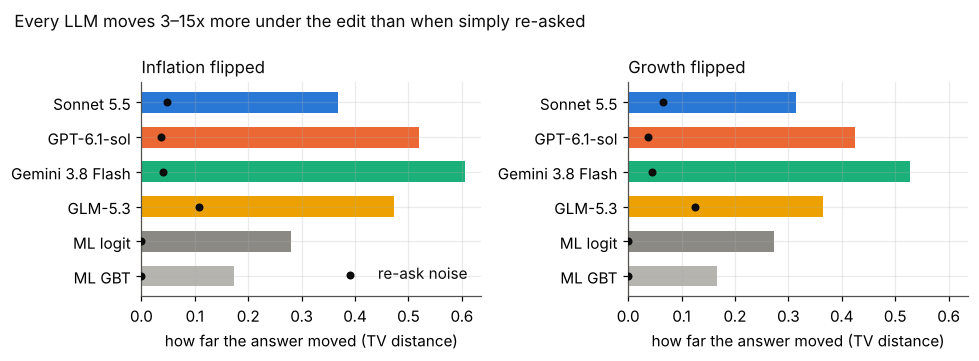

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3), sharex=True)
order = list(NAME)
for ax, e, title in zip(axes, ('infl', 'growth'), ('Inflation flipped', 'Growth flipped')):
    s = sh[sh.edit == e].set_index('forecaster').loc[order]
    y = np.arange(len(s))[::-1]
    ax.barh(y, s.moved_tv, color=[C[k] for k in s.index], height=0.6)
    ax.scatter(s.noise_tv, y, color=INK, zorder=3, s=18, label='re-ask noise')
    ax.set_yticks(y, [NAME[k] for k in s.index]); ax.set_title(title, loc='left', fontsize=11)
    ax.set_xlabel('how far the answer moved (TV distance)')
axes[0].legend(frameon=False, loc='lower right')
fig.suptitle('Every LLM moves 3–15x more under the edit than when simply re-asked', x=0.02, ha='left', fontsize=11)
plt.tight_layout(); plt.show()

In [6]:
v = pd.read_csv(P9 / 'verdict.csv'); v['forecaster'] = v.forecaster.map(NAME); v

,forecaster,edits_scored,reads_data
0,Sonnet 5.5,2,True
1,GPT-6.1-sol,2,True
2,Gemini 3.8 Flash,2,True
3,GLM-5.3,2,True


**Reading.** All four LLMs pass: under either edit their answer moves 0.31–0.61 (total-variation distance), against 0.04–0.13 when the same snapshot is asked again. The deterministic ML models, which cannot remember anything, move less (0.17–0.28).

## 3. Direction (secondary)

Signed shift = change in the probability of the regimes the edit should favour (positive = moved the way the edited figures imply).

In [7]:
t.set_index(['forecaster', 'edit'])[['signed_shift', 'signed_ci_lo', 'signed_ci_hi', 'follow_rate',
    'ignored_rate', 'against_rate']].round(3)

signed_shift  signed_ci_lo  signed_ci_hi  \
forecaster       edit                                               
Sonnet 5.5       infl           0.364         0.314         0.411   
                 growth         0.295         0.227         0.359   
GPT-6.1-sol      infl           0.520         0.456         0.578   
                 growth         0.400         0.301         0.489   
Gemini 3.8 Flash infl           0.604         0.544         0.657   
                 growth         0.503         0.395         0.598   
GLM-5.3          infl           0.472         0.434         0.510   
                 growth         0.343         0.275         0.408   
ML logit         infl           0.107         0.052         0.166   
                 growth        -0.025        -0.104         0.049   
ML GBT           infl           0.058         0.005         0.110   
                 growth        -0.010        -0.051         0.031   

                         follow_rate  ignored_rate  against_rate  
forecaster       edit                                             
Sonnet 5.5       infl          1.000         0.000         0.000  
                 growth        0.900         0.067         0.033  
GPT-6.1-sol      infl          0.967         0.033         0.000  
                 growth        0.867         0.033         0.100  
Gemini 3.8 Flash infl          1.000         0.000         0.000  
                 growth        0.867         0.067         0.067  
GLM-5.3          infl          1.000         0.000         0.000  
                 growth        0.933         0.067         0.000  
ML logit         infl          0.567         0.333         0.100  
                 growth        0.300         0.367         0.333  
ML GBT           infl          0.433         0.400         0.167  
                 growth        0.267         0.400         0.333

**Reading.** The LLMs move the expected way in 87–100% of months, for growth as well as inflation. The ML models follow the inflation edit weakly and the growth edit not at all: fitted on 2008–2026 history, they learned that a strong growth reading often precedes slowing growth. The LLMs instead apply the textbook reading of the regime definitions.

## 4. Does knowing the month make a model ignore the data?

In [8]:
s2 = pd.read_csv(P9 / 'secondary.csv'); s2.round(3)

,comparison,edit,n,mean,ci_lo,ci_hi
0,gpt_sol minus claude_sonnet (moved - noise),infl,30,0.163,0.112,0.215
1,gpt_sol minus claude_sonnet (moved - noise),growth,30,0.136,0.095,0.180
2,claude_sonnet: datable minus not datable (move...,infl,18/12,-0.056,NaN,NaN
3,claude_sonnet: datable minus not datable (move...,growth,11/19,-0.044,NaN,NaN
4,gpt_sol: datable minus not datable (moved - no...,infl,29/1,-0.151,NaN,NaN
5,gpt_sol: datable minus not datable (moved - no...,growth,30/0,NaN,NaN,NaN
6,gemini_flash: datable minus not datable (moved...,infl,22/8,0.054,NaN,NaN
7,gemini_flash: datable minus not datable (moved...,growth,14/16,-0.136,NaN,NaN


**Reading.** No. GPT, which dates almost every one of these snapshots, follows the edits *more* than Sonnet (+0.16 and +0.14 TV, CIs above zero). Within Sonnet and Gemini, months they can date show no consistent difference from months they cannot (small samples; descriptive).

## What we can and cannot claim

* **The calls respond to the data.** Change the figures and every model changes its call, in the direction the figures imply, far beyond its run-to-run noise — including GPT, which knows the month. The answers are therefore not a pure lookup of the month.
* **This does not prove the historical edge is skill.** A model can read the figures *and* lean on what it remembers about what came next. The edits show the data move the answer; they do not show the model stops recognising the original month or that memory adds nothing. That last step needs data no model has seen: the live log.
* **Reading is not the same as being right.** The LLMs apply a momentum reading of growth (strong now → strong next quarter); history partly disagrees, which is one reason their edge over uniform is modest.
* **Limits.** 30 months per edit, one edit size (a full sign flip), one run per edited snapshot. The edited snapshots are internally inconsistent by design (e.g. cooling inflation with unchanged yields), which may itself push answers around; the ML yardstick shows how much a pure data reader moves on the same edits.